# NYC Yellow Taxi Demand Analysis

## Objective

This notebook analyzes the **cleaned January 2025 NYC Yellow Taxi demand samples** created in `02_data_cleaning`.

The goal is to answer four practical demand questions:

1. **When is Yellow Taxi demand highest during the day?**
2. **How do weekday and weekend demand patterns differ?**
3. **Which pickup zones generate the most demand, and how concentrated is demand geographically?**
4. **How does the timing of demand differ across NYC boroughs?**

### Scope

- Yellow Taxi only
- January 2025
- Demand is measured as the **number of pickups**
- Results are descriptive, not causal
- No congestion-pricing analysis or forecasting is performed in this notebook

The citywide sample is used for time-based analysis.  
The zone-level sample is used when a specific pickup location is required.


## 0. Load and Validate the Processed Data

This notebook is designed to run independently from a fresh kernel.

It reads the two Parquet outputs created in `02_data_cleaning`:

- `citywide_demand_2025_01.parquet`
- `zone_demand_2025_01.parquet`

Before analysis, verify that the expected files and columns are available.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

processed_dir = Path("../data/processed")
images_dir = Path("../images")
images_dir.mkdir(parents=True, exist_ok=True)

citywide_path = processed_dir / "citywide_demand_2025_01.parquet"
zone_path = processed_dir / "zone_demand_2025_01.parquet"

for path in [citywide_path, zone_path]:
    if not path.exists():
        raise FileNotFoundError(
            f"{path} was not found. Run 02_data_cleaning.ipynb first."
        )

citywide = pd.read_parquet(citywide_path)
zone = pd.read_parquet(zone_path)

citywide_required = {
    "pickup_date",
    "pickup_hour",
    "pickup_hour_ts",
    "day_of_week",
    "is_weekend",
}

zone_required = {
    "pickup_date",
    "pickup_hour",
    "pickup_hour_ts",
    "is_weekend",
    "pickup_borough",
    "pickup_zone",
}

missing_citywide = sorted(citywide_required - set(citywide.columns))
missing_zone = sorted(zone_required - set(zone.columns))

if missing_citywide or missing_zone:
    raise ValueError(
        f"Missing citywide columns: {missing_citywide}; "
        f"missing zone columns: {missing_zone}"
    )

citywide["pickup_date"] = pd.to_datetime(citywide["pickup_date"])
zone["pickup_date"] = pd.to_datetime(zone["pickup_date"])

print(f"Citywide sample: {len(citywide):,} trips")
print(f"Zone-level sample: {len(zone):,} trips")
print(
    "Date range:",
    citywide["pickup_date"].min().date(),
    "to",
    citywide["pickup_date"].max().date(),
)


Citywide sample: 3,471,950 trips
Zone-level sample: 3,462,487 trips
Date range: 2025-01-01 to 2025-01-31


## Analysis Convention: What Counts as Demand?

Each row represents one cleaned Yellow Taxi trip.

Therefore:

> **Pickup count = trip count = observed demand**

Use pickup counts or average pickups per day for comparisons across hours, weekdays/weekends, zones, and boroughs. This keeps the metric consistent and easy to interpret.


## 1. What Hours of the Day Have the Highest Demand?

### Business Question

At what times of day are Yellow Taxi pickups most concentrated?

### Method

1. Count all pickups for each hour from `0` through `23`.
2. Divide by the number of dates in the sample.
3. Interpret the result as the **average number of pickups during that hour on a typical January day**.

Using a daily average is easier to interpret than a raw monthly total.


In [2]:
number_of_days = citywide["pickup_date"].nunique()

hourly_demand = (
    citywide.groupby("pickup_hour")
    .size()
    .reindex(range(24), fill_value=0)
    .rename("trips_in_month")
    .reset_index()
)

hourly_demand["avg_pickups_per_day"] = hourly_demand["trips_in_month"] / number_of_days

hourly_demand


,pickup_hour,trips_in_month,avg_pickups_per_day
0,0,93340,3010.967742
1,1,64439,2078.677419
2,2,43880,1415.483871
3,3,28471,918.419355
4,4,20012,645.548387
5,5,22533,726.870968
6,6,49998,1612.838710
7,7,102492,3306.193548
8,8,141139,4552.870968
9,9,142713,4603.645161


In [3]:
peak_hours = hourly_demand.sort_values(
    "avg_pickups_per_day",
    ascending=False,
).head(5)

peak_hours


,pickup_hour,trips_in_month,avg_pickups_per_day
18,18,267708,8635.741935
17,17,253248,8169.290323
19,19,220858,7124.451613
16,16,216816,6994.064516
15,15,213462,6885.870968


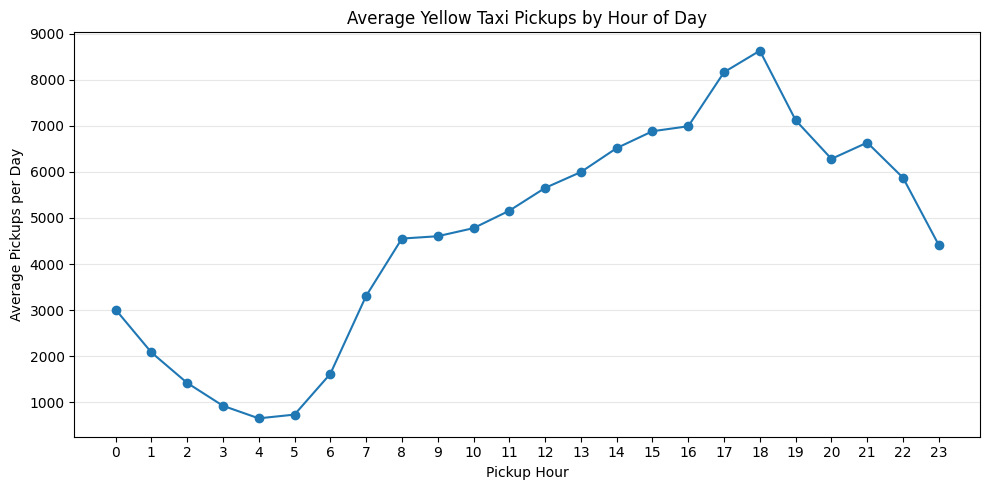

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand["pickup_hour"],
    hourly_demand["avg_pickups_per_day"],
    marker="o",
)

plt.title("Average Yellow Taxi Pickups by Hour of Day")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Pickups per Day")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    images_dir / "03_hourly_demand.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [5]:
peak_row = hourly_demand.loc[hourly_demand["avg_pickups_per_day"].idxmax()]

low_row = hourly_demand.loc[hourly_demand["avg_pickups_per_day"].idxmin()]

print(
    f"Peak demand occurs around {int(peak_row['pickup_hour']):02d}:00, "
    f"with about {peak_row['avg_pickups_per_day']:,.0f} pickups per day."
)

print(
    f"The lowest-demand hour is around {int(low_row['pickup_hour']):02d}:00, "
    f"with about {low_row['avg_pickups_per_day']:,.0f} pickups per day."
)


Peak demand occurs around 18:00, with about 8,636 pickups per day.
The lowest-demand hour is around 04:00, with about 646 pickups per day.


## 2. How Do Weekday and Weekend Demand Patterns Differ?

### Business Question

Does the timing of Yellow Taxi demand change on weekends?

### Method

Raw weekday totals would be misleading because January contains more weekdays than weekend days.

Instead:

1. Count pickups by **date × hour × weekday/weekend status**.
2. Average those hourly counts across dates of the same type.
3. Compare a **typical weekday** with a **typical weekend day**.

This makes the two profiles directly comparable.


In [6]:
daily_hourly = (
    citywide.groupby(["pickup_date", "pickup_hour", "is_weekend"])
    .size()
    .reset_index(name="trip_count")
)

weekday_weekend_profile = (
    daily_hourly.groupby(["is_weekend", "pickup_hour"])["trip_count"]
    .mean()
    .reset_index()
)

weekday_weekend_profile["day_type"] = weekday_weekend_profile["is_weekend"].map(
    {
        False: "Weekday",
        True: "Weekend",
    }
)

weekday_weekend_profile.head()


,is_weekend,pickup_hour,trip_count,day_type
0,False,0,1868.782609,Weekday
1,False,1,1090.347826,Weekday
2,False,2,716.391304,Weekday
3,False,3,504.739130,Weekday
4,False,4,471.956522,Weekday


In [7]:
weekday_weekend_summary = (
    daily_hourly.groupby(["pickup_date", "is_weekend"])["trip_count"]
    .sum()
    .reset_index(name="daily_trips")
    .groupby("is_weekend")["daily_trips"]
    .agg(["mean", "median", "min", "max"])
    .rename(index={False: "Weekday", True: "Weekend"})
)

weekday_weekend_summary


,mean,median,min,max
is_weekend,,,,
Weekday,112767.000,117498.0,80074,138616
Weekend,109788.625,110302.0,79553,136699


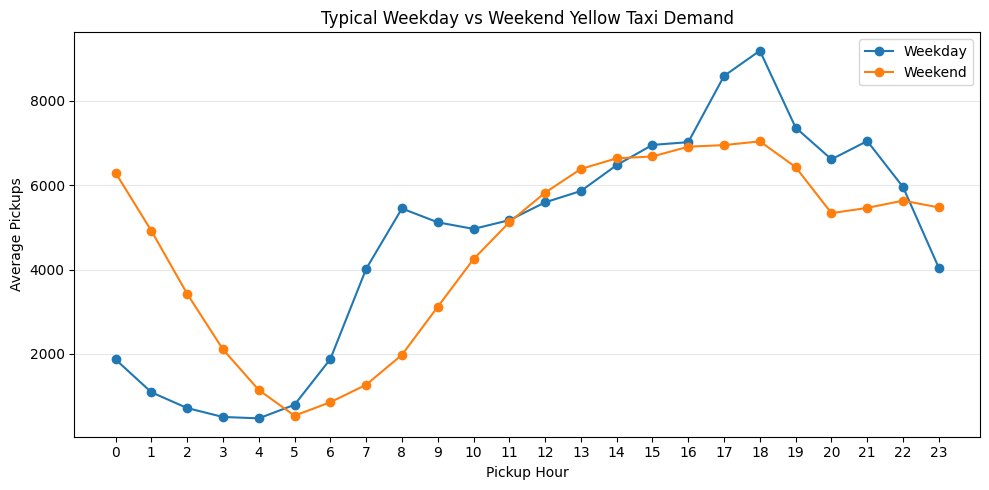

In [8]:
weekday_profile = weekday_weekend_profile[
    weekday_weekend_profile["day_type"] == "Weekday"
]

weekend_profile = weekday_weekend_profile[
    weekday_weekend_profile["day_type"] == "Weekend"
]

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_profile["pickup_hour"],
    weekday_profile["trip_count"],
    marker="o",
    label="Weekday",
)

plt.plot(
    weekend_profile["pickup_hour"],
    weekend_profile["trip_count"],
    marker="o",
    label="Weekend",
)

plt.title("Typical Weekday vs Weekend Yellow Taxi Demand")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Pickups")
plt.xticks(range(24))
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    images_dir / "03_weekday_weekend_demand.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [9]:
weekday_peak = weekday_profile.loc[weekday_profile["trip_count"].idxmax()]

weekend_peak = weekend_profile.loc[weekend_profile["trip_count"].idxmax()]

weekday_avg_daily = weekday_weekend_summary.loc["Weekday", "mean"]
weekend_avg_daily = weekday_weekend_summary.loc["Weekend", "mean"]

print(
    f"Typical weekday peak: {int(weekday_peak['pickup_hour']):02d}:00 "
    f"({weekday_peak['trip_count']:,.0f} pickups on average)."
)

print(
    f"Typical weekend peak: {int(weekend_peak['pickup_hour']):02d}:00 "
    f"({weekend_peak['trip_count']:,.0f} pickups on average)."
)

print(f"Average total pickups per weekday: {weekday_avg_daily:,.0f}.")

print(f"Average total pickups per weekend day: {weekend_avg_daily:,.0f}.")


Typical weekday peak: 18:00 (9,190 pickups on average).
Typical weekend peak: 18:00 (7,041 pickups on average).
Average total pickups per weekday: 112,767.
Average total pickups per weekend day: 109,789.


## 3. Which Pickup Zones Generate the Most Demand?

### Business Question

Where is Yellow Taxi pickup demand geographically concentrated?

### Method

Using the zone-level sample:

1. Count pickups by `pickup_borough` and `pickup_zone`.
2. Rank zones by total trips.
3. Calculate each zone's share of all identifiable pickups.
4. Measure the combined share of the **top 10 pickup zones**.

The top-10 share helps distinguish whether demand is broadly distributed or concentrated in a relatively small number of locations.


In [10]:
zone_summary = (
    zone.groupby(["pickup_borough", "pickup_zone"])
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
    .reset_index(drop=True)
)

total_zone_trips = zone_summary["trip_count"].sum()

zone_summary["trip_share_pct"] = zone_summary["trip_count"] / total_zone_trips * 100

zone_summary["zone_label"] = (
    zone_summary["pickup_zone"] + " (" + zone_summary["pickup_borough"] + ")"
)

top_10_zones = zone_summary.head(10).copy()

top_10_share = top_10_zones["trip_count"].sum() / total_zone_trips * 100

top_10_zones[
    [
        "pickup_borough",
        "pickup_zone",
        "trip_count",
        "trip_share_pct",
    ]
]


,pickup_borough,pickup_zone,trip_count,trip_share_pct
0,Manhattan,Midtown Center,169797,4.903903
1,Manhattan,Upper East Side South,163491,4.721779
2,Manhattan,Upper East Side North,155436,4.489143
3,Queens,JFK Airport,146002,4.216680
4,Manhattan,Times Sq/Theatre District,125744,3.631609
5,Manhattan,Penn Station/Madison Sq West,119050,3.438280
6,Manhattan,Midtown East,117838,3.403276
7,Manhattan,Lincoln Square East,110472,3.190539
8,Manhattan,Upper West Side South,96526,2.787765
9,Manhattan,Midtown North,95828,2.767606


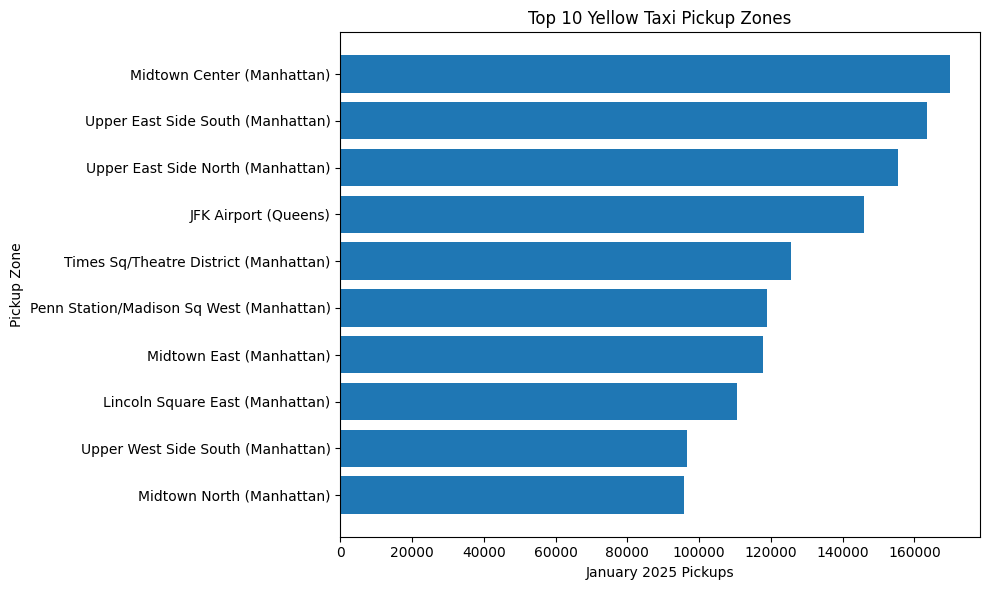

In [11]:
chart_zones = top_10_zones.sort_values(
    "trip_count",
    ascending=True,
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_zones["zone_label"],
    chart_zones["trip_count"],
)

plt.title("Top 10 Yellow Taxi Pickup Zones")
plt.xlabel("January 2025 Pickups")
plt.ylabel("Pickup Zone")
plt.tight_layout()

plt.savefig(
    images_dir / "03_top_pickup_zones.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [12]:
top_zone = top_10_zones.iloc[0]

print(
    f"The busiest pickup zone is {top_zone['pickup_zone']} "
    f"({top_zone['pickup_borough']}), with "
    f"{top_zone['trip_count']:,} trips "
    f"({top_zone['trip_share_pct']:.1f}% of zone-level demand)."
)

print(
    f"The top 10 pickup zones account for "
    f"{top_10_share:.1f}% of all zone-level pickups."
)


The busiest pickup zone is Midtown Center (Manhattan), with 169,797 trips (4.9% of zone-level demand).
The top 10 pickup zones account for 37.6% of all zone-level pickups.


## 4. How Does Demand Vary by Borough and Hour?

### Business Question

Do different boroughs show different time-of-day demand patterns?

### Method

Use two complementary views:

1. **Borough demand share** — shows which boroughs contribute the most pickup volume overall.
2. **Within-borough hourly profile** — converts each borough's hourly demand into a percentage of that borough's own daily pickups.

The normalized hourly profile is useful because Manhattan's absolute Yellow Taxi volume is much larger than other boroughs. Without normalization, smaller boroughs would be difficult to compare.


In [13]:
borough_summary = (
    zone.groupby("pickup_borough")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
    .reset_index(drop=True)
)

borough_summary["trip_share_pct"] = (
    borough_summary["trip_count"] / borough_summary["trip_count"].sum() * 100
)

borough_summary


,pickup_borough,trip_count,trip_share_pct
0,Manhattan,3086504,89.141244
1,Queens,294627,8.509115
2,Brooklyn,66010,1.906433
3,Bronx,14717,0.425041
4,EWR,376,0.010859
5,Staten Island,253,0.007307


In [14]:
borough_hourly = (
    zone.groupby(["pickup_borough", "pickup_hour"])
    .size()
    .unstack("pickup_hour", fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

borough_hourly_pct = (
    borough_hourly.div(
        borough_hourly.sum(axis=1),
        axis=0,
    )
    * 100
)

borough_order = borough_summary["pickup_borough"].tolist()

borough_hourly_pct = borough_hourly_pct.loc[borough_order]

borough_hourly_pct


pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_borough,,,,,,,,,,,,,,,,,,,,,
Manhattan,2.591994,1.868846,1.286050,0.810723,0.511971,0.520913,1.252647,2.774757,4.028020,4.142745,...,5.810133,6.132213,6.233395,7.460544,7.970280,6.466831,5.627143,5.972259,5.218266,3.754896
Queens,3.502734,1.537537,0.764356,0.579037,0.758926,1.384123,2.343981,3.380546,3.178935,3.243762,...,6.250276,6.830331,7.098806,6.315443,5.772383,6.039840,6.209546,6.354815,5.873868,5.712647
Brooklyn,3.691865,2.763218,2.419330,2.214816,2.261779,2.423875,4.319043,7.291319,8.333586,5.961218,...,4.476594,4.217543,3.522194,4.740191,5.473413,3.934252,3.116195,3.019240,4.329647,4.714437
Bronx,2.167561,1.508460,1.413332,1.311409,2.690766,4.681661,9.193450,11.721139,10.171910,6.326018,...,4.797173,3.859482,3.478970,3.941021,2.860637,2.106408,2.065638,1.916151,2.792689,3.309098
EWR,0.000000,0.265957,0.265957,0.797872,1.329787,0.797872,2.659574,3.191489,1.861702,4.787234,...,10.638298,13.829787,13.031915,10.372340,5.053191,5.319149,2.659574,2.393617,0.000000,1.063830
Staten Island,4.347826,1.185771,2.371542,1.581028,1.976285,5.138340,4.347826,11.462451,10.276680,1.976285,...,5.928854,6.324111,3.952569,0.790514,2.371542,2.371542,1.976285,2.766798,3.952569,5.533597


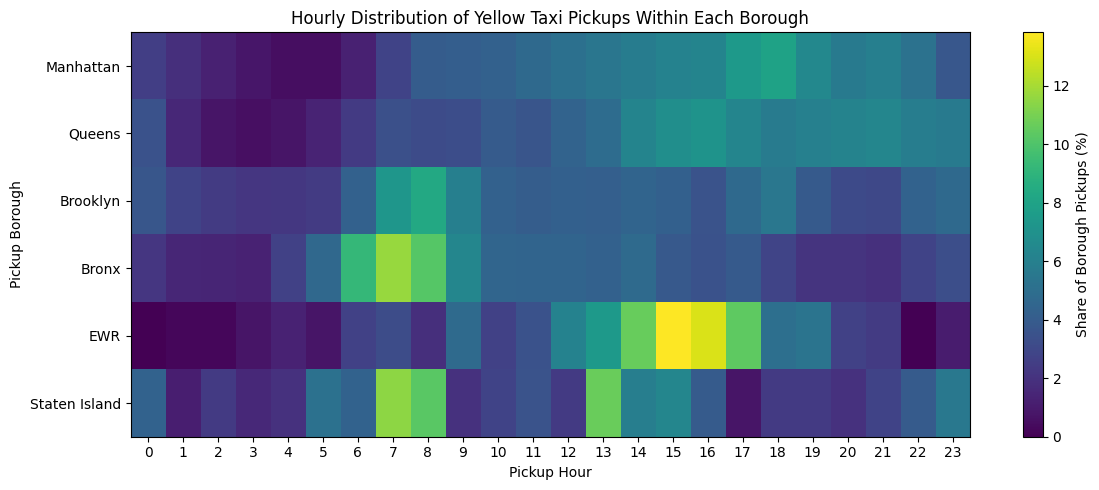

In [15]:
plt.figure(figsize=(12, 5))

plt.imshow(
    borough_hourly_pct,
    aspect="auto",
)

plt.title("Hourly Distribution of Yellow Taxi Pickups Within Each Borough")
plt.xlabel("Pickup Hour")
plt.ylabel("Pickup Borough")

plt.xticks(
    ticks=range(24),
    labels=range(24),
)

plt.yticks(
    ticks=range(len(borough_hourly_pct.index)),
    labels=borough_hourly_pct.index,
)

plt.colorbar(label="Share of Borough Pickups (%)")
plt.tight_layout()

plt.savefig(
    images_dir / "03_borough_hourly_profile.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [16]:
largest_borough = borough_summary.iloc[0]

borough_peak_hours = borough_hourly_pct.idxmax(axis=1).rename("peak_hour").reset_index()

print(
    f"{largest_borough['pickup_borough']} accounts for "
    f"{largest_borough['trip_share_pct']:.1f}% of identifiable "
    f"Yellow Taxi pickup demand."
)

borough_peak_hours


Manhattan accounts for 89.1% of identifiable Yellow Taxi pickup demand.


,pickup_borough,peak_hour
0,Manhattan,18
1,Queens,16
2,Brooklyn,8
3,Bronx,7
4,EWR,15
5,Staten Island,7


## 5. Executive Summary

The cells below summarize the main descriptive findings.

The statements are generated from the analysis outputs rather than written in advance.


In [17]:
print("NYC Yellow Taxi Demand Analysis — January 2025")
print("-" * 52)

print(
    f"1. Peak hour: {int(peak_row['pickup_hour']):02d}:00 "
    f"(~{peak_row['avg_pickups_per_day']:,.0f} pickups per day)."
)

print(
    f"2. Weekday peak: {int(weekday_peak['pickup_hour']):02d}:00; "
    f"weekend peak: {int(weekend_peak['pickup_hour']):02d}:00."
)

print(
    f"3. Busiest pickup zone: {top_zone['pickup_zone']} ({top_zone['pickup_borough']})."
)

print(
    f"4. Top 10 pickup zones represent "
    f"{top_10_share:.1f}% of identifiable pickup demand."
)

print(
    f"5. Largest borough by pickup volume: "
    f"{largest_borough['pickup_borough']} "
    f"({largest_borough['trip_share_pct']:.1f}% of zone-level pickups)."
)


NYC Yellow Taxi Demand Analysis — January 2025
----------------------------------------------------
1. Peak hour: 18:00 (~8,636 pickups per day).
2. Weekday peak: 18:00; weekend peak: 18:00.
3. Busiest pickup zone: Midtown Center (Manhattan).
4. Top 10 pickup zones represent 37.6% of identifiable pickup demand.
5. Largest borough by pickup volume: Manhattan (89.1% of zone-level pickups).


## 6. Limitations and Next Step

### Limitations

- The analysis covers **January 2025 only**.
- It describes **Yellow Taxi** demand, not all NYC ride-hailing activity.
- Pickup counts measure observed trip demand; they do not directly measure unmet demand or taxi supply.
- The analysis is descriptive and does not explain why a demand pattern occurred.
- Results may differ by season, weather, holidays, or broader transportation conditions.

### Next Step

The next notebook will extend the project to multiple periods and examine **congestion-pricing-related changes** using careful descriptive comparisons before making any causal claims.
